In [ ]:
import numpy as np
import scipy.stats as stats

n = 1006;  phat = 0.51;  p0 = 0.50;  alpha = 0.10

# Conditions
print(f"n*p0 = {n*p0},  n*(1-p0) = {n*(1-p0)}")

# Test statistic
se = np.sqrt(p0*(1-p0)/n)
z = (phat - p0) / se
pval = 1 - stats.norm.cdf(z)
print(f"SE = {round(se,6)},  z = {round(z,4)},  p-value = {round(pval,4)}")

# 90% Confidence Interval
z_star = stats.norm.ppf(0.95)
se_ci = np.sqrt(phat*(1-phat)/n)
lower = phat - z_star*se_ci
upper = phat + z_star*se_ci
me = z_star*se_ci
print(f"90% CI: ({round(lower,4)}, {round(upper,4)}),  ME = {round(me,4)}")

n*p0 = 503.0,  n*(1-p0) = 503.0
SE = 0.015764,  z = 0.6344,  p-value = 0.2629
90% CI: (0.4841, 0.5359),  ME = 0.0259


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

sm_data = pd.read_csv('social_media.csv')
ct = pd.crosstab(sm_data['AgeGroup'], sm_data['Hard'])
print(ct)

chi2, pval, dof, expected = stats.chi2_contingency(ct)
print(f"Expected counts:\n{np.round(expected, 2)}")
print(f"Chi2 = {round(chi2,4)},  df = {dof},  p-value = {round(pval,4)}")

# Two-sample z-test
n_over = 1073;  x_over = 409;  p_over = 409/1073
n_under = 880;  x_under = 391;  p_under = 391/880
p_pool = (409+391)/(1073+880)
se_pool = np.sqrt(p_pool*(1-p_pool)*(1/n_over + 1/n_under))
z = (p_over - p_under) / se_pool
pval_z = 2*(1 - stats.norm.cdf(abs(z)))
print(f"p_over={round(p_over,4)},  p_under={round(p_under,4)},  p_pool={round(p_pool,4)}")
print(f"z = {round(z,4)},  p-value (two-sided) = {round(pval_z,4)}")

# 95% CI
se_ci = np.sqrt(p_over*(1-p_over)/n_over + p_under*(1-p_under)/n_under)
z_star = stats.norm.ppf(0.975)
diff = p_over - p_under
print(f"95% CI: ({round(diff - z_star*se_ci,4)}, {round(diff + z_star*se_ci,4)})")

# One-sided test
z_os = (p_under - p_over) / se_pool
pval_os = 1 - stats.norm.cdf(z_os)
print(f"One-sided (Ha: p_under > p_over): z={round(z_os,4)},  p={round(pval_os,4)}")

Hard       no  yes
AgeGroup          
Over50    664  409
Under50   489  391
Expected counts:
[[633.47 439.53]
 [519.53 360.47]]
Chi2 = 7.7123,  df = 1,  p-value = 0.0055
p_over=0.3812,  p_under=0.4443,  p_pool=0.4096
z = -2.8233,  p-value (two-sided) = 0.0048
95% CI: (-0.107, -0.0193)
One-sided (Ha: p_under > p_over): z=2.8233,  p=0.0024


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

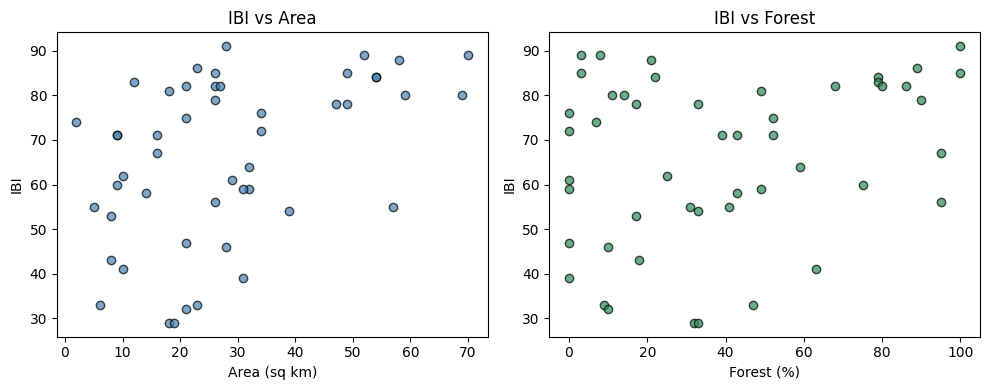

                            OLS Regression Results                            
Dep. Variable:                    IBI   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     12.78
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           3.86e-05
Time:                        23:22:02   Log-Likelihood:                -200.58
No. Observations:                  49   AIC:                             407.2
Df Residuals:                      46   BIC:                             412.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.6292      5.461      7.439      0.0

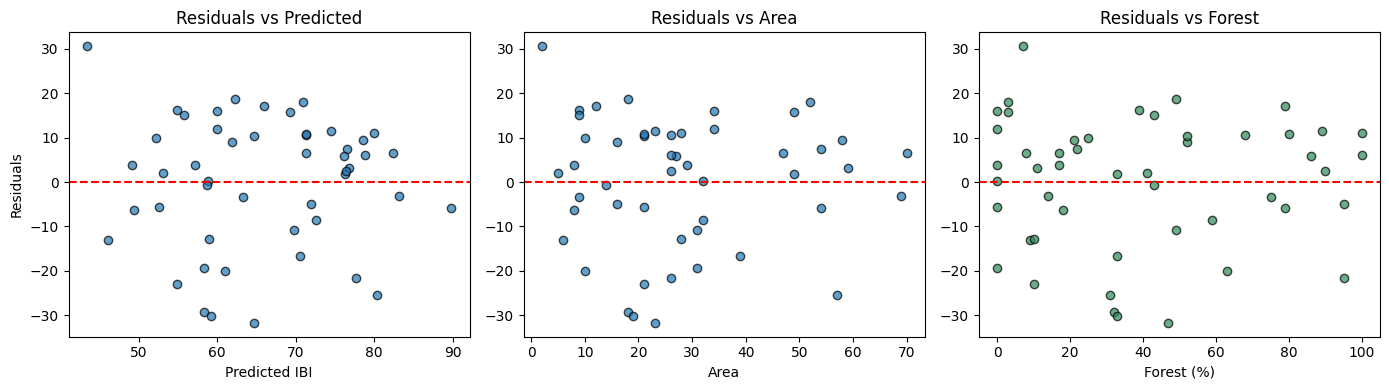

      mean  mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  91.5744   5.5602        80.3822       102.7665       59.4265      123.7222
Forest slope 95% CI: (0.0939, 0.3734)


In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

ozark = pd.read_csv('ozark.csv')

# Scatterplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(ozark['Area'], ozark['IBI'], color='steelblue', edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Area (sq km)');  axes[0].set_ylabel('IBI')
axes[0].set_title('IBI vs Area')
axes[1].scatter(ozark['Forest'], ozark['IBI'], color='seagreen', edgecolor='k', alpha=0.7)
axes[1].set_xlabel('Forest (%)');  axes[1].set_ylabel('IBI')
axes[1].set_title('IBI vs Forest')
plt.tight_layout();  plt.show()

# MLR model
X = sm.add_constant(ozark[['Area', 'Forest']])
y = ozark['IBI']
model = sm.OLS(y, X).fit()
print(model.summary())

# Residual plots
m_resid = model.resid;  m_pred = model.fittedvalues
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(m_pred, m_resid, edgecolor='k', alpha=0.7);  axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted IBI');  axes[0].set_ylabel('Residuals');  axes[0].set_title('Residuals vs Predicted')
axes[1].scatter(ozark['Area'], m_resid, edgecolor='k', alpha=0.7);  axes[1].axhline(0, color='red', ls='--')
axes[1].set_xlabel('Area');  axes[1].set_title('Residuals vs Area')
axes[2].scatter(ozark['Forest'], m_resid, color='seagreen', edgecolor='k', alpha=0.7);  axes[2].axhline(0, color='red', ls='--')
axes[2].set_xlabel('Forest (%)');  axes[2].set_title('Residuals vs Forest')
plt.tight_layout();  plt.show()

# Prediction and intervals
Xnew = pd.DataFrame([[1, 55, 84]])
pred_obj = model.get_prediction(Xnew)
print(pred_obj.summary_frame(alpha=0.05).round(4))

# 95% CI for Forest slope
b_f = model.params['Forest'];  se_f = model.bse['Forest']
t_star = stats.t.ppf(0.975, model.df_resid)
print(f"Forest slope 95% CI: ({round(b_f - t_star*se_f, 4)}, {round(b_f + t_star*se_f, 4)})")


In [3]:
import scipy.stats as stats

MS_reg = 2840.4 / 2       # = 1420.2
MS_res = 7491.8 / 77      # = 97.30
F = MS_reg / MS_res
pval = 1 - stats.f.cdf(F, 2, 77)
print(f"MS_reg={round(MS_reg,4)},  MS_res={round(MS_res,4)},  F={round(F,4)},  p-value={round(pval,8)}")

# Partial F-test for adding ACT scores
extra_SS = 2986.2 - 2840.4
MS_extra = extra_SS / 2
MS_res_full = 7346.0 / 75
F_part = MS_extra / MS_res_full
pval_part = 1 - stats.f.cdf(F_part, 2, 75)
print(f"Partial F: F={round(F_part,4)},  p-value={round(pval_part,4)}")

MS_reg=1420.2,  MS_res=97.2961,  F=14.5967,  p-value=4.22e-06
Partial F: F=0.7443,  p-value=0.4786
